In [2]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/yuyuezhu/Desktop/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [3]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [4]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.3075337080446443),
 'd_ln_sigma_d_alpha': np.float64(2.78364942646351),
 'd_ln_sigma_d_beta': np.float64(-0.7671990084031498),
 'd_ln_sigma_d_rho': np.float64(0.0047994361581260095),
 'd_ln_sigma_d_nu': np.float64(0.017789228437936306),
 'd_ln_sigma_d_forward': np.float64(-2.3980198155653976),
 'd_ln_sigma_d_strike': np.float64(0.8458659814736342),
 'd_ln_sigma_d_strike_strike': np.float64(14.983951453889139),
 'd_ln_sigma_d_tte': np.float64(0.007562343085309909)}

In [5]:
import numpy as np
from scipy.optimize import root_scalar
import scipy.stats as si

# from fixedincomelib import qfEuropeanOptionsSABRLogNormalSigma

# ==========================================
# Task 1: Solver to back out alpha from LN ATM Vol
# ==========================================
def solve_alpha_from_atm_ln_vol(sigma_ln_atm, f, shift, tte, beta, rho, nu):
    f_shift = f + shift
    
    # Coefficients for the cubic polynomial in A: f(A) = A * (1 + C3 + C2*A + C1*A^2)
    C1 = (1 - beta)**2 / 24.0 * tte
    C2 = beta * rho * nu / 4.0 * tte
    C3 = (2 - 3 * rho**2) * nu**2 / 24.0 * tte

    def obj(A):
        return A * (1 + C3 + C2 * A + C1 * A**2) - sigma_ln_atm

    def obj_prime(A):
        return (1 + C3) + 2 * C2 * A + 3 * C1 * A**2

    # A is approximately sigma_ln_atm (initial guess for Newton method)
    res = root_scalar(obj, fprime=obj_prime, x0=sigma_ln_atm, method='newton')
    
    if not res.converged:
        raise ValueError("Root solver failed to converge for alpha.")
        
    A_sol = res.root
    alpha = A_sol * (f_shift)**(1 - beta)
    return alpha


# ==========================================
# Task 2: Implement sensitivity of alpha w.r.t parameters
# ==========================================
def alpha_sensitivities_ln(sigma_ln_atm, f, shift, tte, beta, rho, nu, alpha=None):
    f_shift = f + shift
    if alpha is None:
        alpha = solve_alpha_from_atm_ln_vol(sigma_ln_atm, f, shift, tte, beta, rho, nu)

    A = alpha / (f_shift)**(1 - beta)
    
    C1 = (1 - beta)**2 / 24.0 * tte
    C2 = beta * rho * nu / 4.0 * tte
    C3 = (2 - 3 * rho**2) * nu**2 / 24.0 * tte

    # df / dA
    df_dA = (1 + C3) + 2 * C2 * A + 3 * C1 * A**2

    # 1. d_alpha / d_sigma_ln_atm (Implicit Function Theorem)
    dA_dsigma_ln = 1.0 / df_dA
    dalpha_dsigma_ln = dA_dsigma_ln * (f_shift)**(1 - beta)

    # 2. d_alpha / d_F (Analytical backbone of SABR)
    dalpha_dF = alpha * (1 - beta) / f_shift

    # 3. d_alpha / d_beta
    df_dbeta_coeff = A * (A * (rho * nu / 4.0 * tte) + A**2 * (-2 * (1 - beta) / 24.0 * tte))
    dA_dbeta = - df_dbeta_coeff / df_dA
    dalpha_dbeta = dA_dbeta * (f_shift)**(1 - beta) - alpha * np.log(f_shift)

    # 4. d_alpha / d_nu
    df_dnu_coeff = A * ( (2 - 3 * rho**2) * nu / 12.0 * tte + A * (rho * beta / 4.0 * tte) )
    dA_dnu = - df_dnu_coeff / df_dA
    dalpha_dnu = dA_dnu * (f_shift)**(1 - beta)

    # 5. d_alpha / d_rho
    df_drho_coeff = A * ( -rho * nu**2 / 4.0 * tte + A * (beta * nu / 4.0 * tte) )
    dA_drho = - df_drho_coeff / df_dA
    dalpha_drho = dA_drho * (f_shift)**(1 - beta)

    return {
        'alpha': alpha,
        'dalpha_dsigma_ln': dalpha_dsigma_ln,
        'dalpha_dF': dalpha_dF,
        'dalpha_dbeta': dalpha_dbeta,
        'dalpha_dnu': dalpha_dnu,
        'dalpha_drho': dalpha_drho
    }


# ==========================================
# Task 3: Conversion from Normal ATM Vol & Chain Rule
# ==========================================
def normal_to_lognormal_atm(sigma_n_atm, f_shift):
    """
    NOTE: Replace this with the exact formula from your last homework.
    This is a standard first-order Bachelier to Black ATM conversion proxy.
    """
    sigma_ln = sigma_n_atm / f_shift
    dsigma_ln_dsigma_n = 1.0 / f_shift
    dsigma_ln_dF = -sigma_n_atm / (f_shift**2)
    return sigma_ln, dsigma_ln_dsigma_n, dsigma_ln_dF

def alpha_sensitivities_normal(sigma_n_atm, f, shift, tte, beta, rho, nu):
    f_shift = f + shift
    
    # Get LN equivalent and its derivatives w.r.t Normal Vol and F
    sigma_ln_atm, dsig_ln_dsig_n, dsig_ln_dF = normal_to_lognormal_atm(sigma_n_atm, f_shift)
    
    # Get base sensitivities under LN parameterization (Task 2)
    ln_sens = alpha_sensitivities_ln(sigma_ln_atm, f, shift, tte, beta, rho, nu)
    
    # Apply Chain Rule (Task 3 Core Requirement)
    dalpha_dsigma_n = ln_sens['dalpha_dsigma_ln'] * dsig_ln_dsig_n
    
    # Total derivative of alpha w.r.t F includes the shift in the ATM volatility itself
    dalpha_dF_total = ln_sens['dalpha_dF'] + ln_sens['dalpha_dsigma_ln'] * dsig_ln_dF

    return {
        'alpha': ln_sens['alpha'],
        'dalpha_dsigma_n': dalpha_dsigma_n,
        'dalpha_dF': dalpha_dF_total, # This is the chained partial
        'dalpha_dbeta': ln_sens['dalpha_dbeta'],
        'dalpha_dnu': ln_sens['dalpha_dnu'],
        'dalpha_drho': ln_sens['dalpha_drho']
    }


# ==========================================
# Task 4: SABR Risk under Normal ATM Parameterization
# ==========================================
def black_76_price_and_greeks(f, k, t, v, is_call=True):
    # Standard Black-76 (Shifted Black) formula
    d1 = (np.log(f / k) + 0.5 * v**2 * t) / (v * np.sqrt(t))
    d2 = d1 - v * np.sqrt(t)
    
    phi = 1 if is_call else -1
    price = phi * f * si.norm.cdf(phi * d1) - phi * k * si.norm.cdf(phi * d2)
    
    # Greeks w.r.t the underlying components
    bs_delta = phi * si.norm.cdf(phi * d1)
    bs_vega = f * si.norm.pdf(d1) * np.sqrt(t)
    
    return price, bs_delta, bs_vega

def calculate_sabr_risk(sigma_n_atm, f, strike, shift, tte, beta, rho, nu, is_call=True):
    # 1. Parameter Conversion & Sensitivities
    sens_N = alpha_sensitivities_normal(sigma_n_atm, f, shift, tte, beta, rho, nu)
    alpha = sens_N['alpha']
    
    f_shift = f + shift
    k_shift = strike + shift
    
    # 2. Get SABR Volatility for the specific strike using the provided library func
    sigma_sabr = qfEuropeanOptionsSABRLogNormalSigma(f, strike, tte, alpha, beta, rho, nu, shift, True)
    
    # 3. Calculate Black Price and base BS-Greeks
    price, bs_delta, bs_vega = black_76_price_and_greeks(f_shift, k_shift, tte, sigma_sabr, is_call)
    
    # 4. Calculate dSigma/dF and dSigma/dAlpha via finite difference (bump)
    # Since analytical off-ATM derivatives are extremely complex, FD is industry standard here.
    bump = 1e-5
    
    vol_F_up = qfEuropeanOptionsSABRLogNormalSigma(f + bump, strike, tte, alpha, beta, rho, nu, shift, True)
    vol_F_dn = qfEuropeanOptionsSABRLogNormalSigma(f - bump, strike, tte, alpha, beta, rho, nu, shift, True)
    dVol_dF_direct = (vol_F_up - vol_F_dn) / (2 * bump)
    
    vol_a_up = qfEuropeanOptionsSABRLogNormalSigma(f, strike, tte, alpha + bump, beta, rho, nu, shift, True)
    vol_a_dn = qfEuropeanOptionsSABRLogNormalSigma(f, strike, tte, alpha - bump, beta, rho, nu, shift, True)
    dVol_dalpha = (vol_a_up - vol_a_dn) / (2 * bump)
    
    # 5. Chain Rule for SABR Greeks
    # SABR Delta = dV/dF = BS_Delta + BS_Vega * (dVol/dF_direct + dVol/dalpha * dalpha/dF_total)
    total_dVol_dF = dVol_dF_direct + dVol_dalpha * sens_N['dalpha_dF']
    sabr_delta = bs_delta + bs_vega * total_dVol_dF
    
    # SABR Vega = dV/dSigma_N = BS_Vega * dVol/dalpha * dalpha/dSigma_N
    sabr_vega_N = bs_vega * dVol_dalpha * sens_N['dalpha_dsigma_n']
    
    return {
        'Price': price,
        'SABR_Delta': sabr_delta,
        'SABR_Vega_N': sabr_vega_N,
        'Implied_SABR_Vol': sigma_sabr,
        'Backed_out_Alpha': alpha
    }

# 2. Detection of Negative Density

The parameters set is:

In [6]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

negative density detected. strike range: [0.000100, 0.005759]


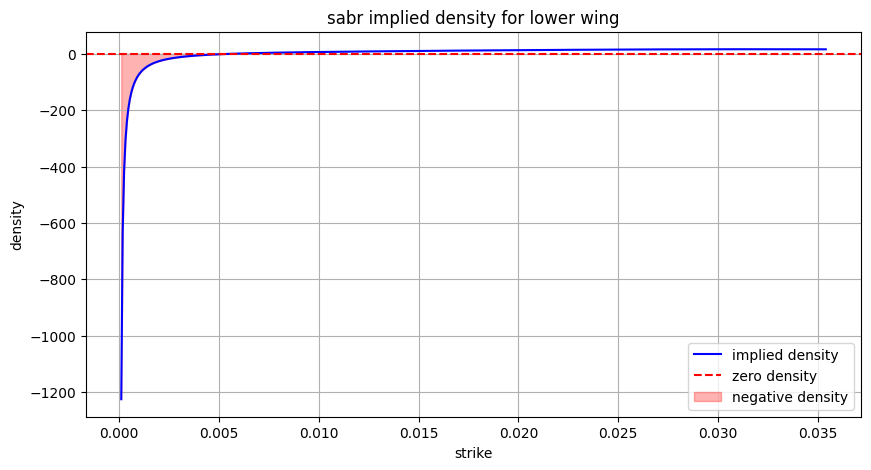

In [7]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

# given parameters for lower wing
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5 / 100
shift = 0.0
forward = 3.54 / 100
tte = 10.0

# standard black-76 pricing formula
def black_76_call(F, K, T, vol, shift=0.0):
    F_s = F + shift
    K_s = K + shift
    
    # handle non-positive inputs
    if K_s <= 0 or F_s <= 0:
        return max(F_s - K_s, 0.0)
        
    d1 = (np.log(F_s / K_s) + 0.5 * vol**2 * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    
    return F_s * si.norm.cdf(d1) - K_s * si.norm.cdf(d2)

# approximate density using central finite difference
def calculate_sabr_density(K, F, T, alpha, beta, rho, nu, shift, dK=1e-5):
    # compute sabr implied volatilities at k+dk, k, k-dk
    res_plus  = qfEuropeanOptionSABRLogNormalSigma(F, K + dK, T, alpha, beta, rho, nu, shift, True)
    res_0     = qfEuropeanOptionSABRLogNormalSigma(F, K, T, alpha, beta, rho, nu, shift, True)
    res_minus = qfEuropeanOptionSABRLogNormalSigma(F, K - dK, T, alpha, beta, rho, nu, shift, True)
    
    # extract float values from dictionaries
    vol_plus  = list(res_plus.values())[0]
    vol_0     = list(res_0.values())[0]
    vol_minus = list(res_minus.values())[0]
    
    # compute corresponding option prices
    c_plus  = black_76_call(F, K + dK, T, vol_plus, shift)
    c_0     = black_76_call(F, K, T, vol_0, shift)
    c_minus = black_76_call(F, K - dK, T, vol_minus, shift)
    
    # compute second derivative
    density = (c_plus - 2 * c_0 + c_minus) / (dK**2)
    return density

# search for negative density regions in the lower wing
def detect_negative_density():
    # generate strike grid strictly greater than zero up to forward
    strikes = np.linspace(0.0001, forward, 500)
    densities = []
    
    for K in strikes:
        dens = calculate_sabr_density(K, forward, tte, alpha, beta, rho, nu, shift)
        densities.append(dens)
        
    densities = np.array(densities)
    
    # identify indices of negative density
    negative_idx = np.where(densities < 0)[0]
    
    if len(negative_idx) > 0:
        neg_strikes = strikes[negative_idx]
        print(f"negative density detected. strike range: [{neg_strikes[0]:.6f}, {neg_strikes[-1]:.6f}]")
    else:
        print("no negative density detected.")
        
    # plot implied density distribution
    plt.figure(figsize=(10, 5))
    plt.plot(strikes, densities, label="implied density", color='blue')
    plt.axhline(0, color='red', linestyle='--', label="zero density")
    plt.fill_between(strikes, densities, 0, where=(densities < 0), color='red', alpha=0.3, label='negative density')
    plt.title("sabr implied density for lower wing")
    plt.xlabel("strike")
    plt.ylabel("density")
    plt.legend()
    plt.grid(True)
    plt.show()

# execute detection
detect_negative_density()

# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

calculating analytic density...
simulating 1000 paths...
simulating 10000 paths...
simulating 100000 paths...


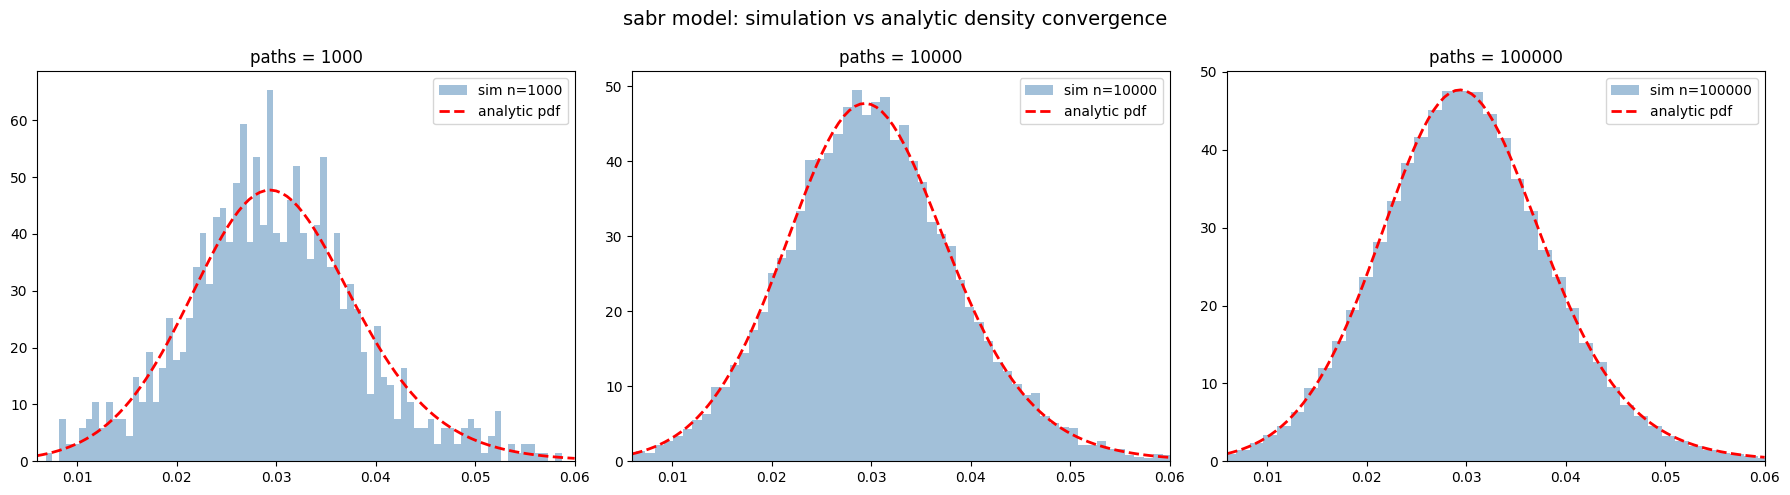

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import sys
import os

# add local path so python finds the library
sys.path.append(os.getcwd())

# import your provided classes
from fixedincomelib.analytics.european_options import EuropeanOptionAnalytics, CallOrPut, SimpleMetrics

# --- 1. sabr simulation function ---
def simulate_sabr(f0, alpha, beta, rho, volvol, tte, num_paths, num_steps):
    """simulate paths using euler scheme"""
    dt = tte / num_steps
    sqrt_dt = np.sqrt(dt)
    
    f = np.full(num_paths, float(f0))
    a = np.full(num_paths, float(alpha))
    
    rho_comp = np.sqrt(1 - rho**2)
    
    for _ in range(num_steps):
        # generate correlated random noise
        z1 = np.random.normal(0, 1, num_paths)
        z2 = np.random.normal(0, 1, num_paths)
        
        dw1 = sqrt_dt * z1
        dw2 = sqrt_dt * (rho * z1 + rho_comp * z2)
        
        # update forward price (stay above zero)
        f = np.maximum(f, 1e-9)
        f += a * (f**beta) * dw1
        
        # update volatility process
        a *= np.exp(volvol * dw2 - 0.5 * volvol**2 * dt)
        
    return f

# --- 2. analytic volatility (hagan formula) ---
def get_hagan_vol(f, k, t, alpha, beta, rho, volvol):
    """approximate implied vol using hagan formula"""
    if f <= 0 or k <= 0: return alpha 
    
    if abs(f - k) < 1e-7: # atm case
        v_atm = alpha / (f**(1-beta))
        adj = ( (1-beta)**2/24 * alpha**2/(f**(2-2*beta)) + 0.25*rho*beta*volvol*alpha/(f**(1-beta)) + (2-3*rho**2)/24 * volvol**2 )
        return v_atm * (1 + adj * t)
    
    # non-atm case
    f_mid = np.sqrt(f * k)
    log_fk = np.log(f / k)
    z = (volvol / alpha) * (f_mid**(1-beta)) * log_fk
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    
    sigma = (alpha / (f_mid**(1-beta) * (1 + ((1-beta)**2/24) * log_fk**2))) * (z / x_z)
    adj = 1 + ( ((1-beta)**2/24)*alpha**2/(f_mid**(2-2*beta)) + 0.25*rho*beta*volvol*alpha/(f_mid**(1-beta)) + (2-3*rho**2)/24 * volvol**2 ) * t
    return sigma * adj

# --- 3. compute option price ---
def sabr_price(f0, k, tte, alpha, beta, rho, volvol):
    """calculate call price using black model and hagan vol"""
    sig = get_hagan_vol(f0, k, tte, alpha, beta, rho, volvol)
    res = EuropeanOptionAnalytics.european_option_log_normal(
        forward=f0, strike=k, time_to_expiry=tte, log_normal_sigma=sig, option_type=CallOrPut.CALL
    )
    return res[SimpleMetrics.PV]

# --- 4. visualization ---
def visualize_sabr_convergence():
    # model parameters
    f0, alpha, beta, rho, volvol, tte = 0.03, 0.05, 0.5, -0.2, 0.4, 1.0
    path_list = [1000, 10000, 100000]
    
    # define strike range for pdf calculation
    strikes = np.linspace(f0 * 0.2, f0 * 2.0, 100)
    eps = f0 * 0.01 # small shift for derivative
    
    # calculate analytic pdf using second derivative of call price
    print("calculating analytic density...")
    pdf_vals = []
    for k in strikes:
        c_up = sabr_price(f0, k + eps, tte, alpha, beta, rho, volvol)
        c_mid = sabr_price(f0, k, tte, alpha, beta, rho, volvol)
        c_down = sabr_price(f0, k - eps, tte, alpha, beta, rho, volvol)
        density = (c_up - 2 * c_mid + c_down) / (eps**2)
        pdf_vals.append(max(0, density))

    # create plots for different path counts
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, n in enumerate(path_list):
        print(f"simulating {n} paths...")
        f_end = simulate_sabr(f0, alpha, beta, rho, volvol, tte, num_paths=n, num_steps=100)
        
        # plot histogram of simulated terminal values
        axes[i].hist(f_end, bins=80, density=True, alpha=0.5, color='steelblue', label=f'sim n={n}')
        # plot analytic pdf curve
        axes[i].plot(strikes, pdf_vals, 'r--', lw=2, label='analytic pdf')
        
        axes[i].set_title(f'paths = {n}')
        axes[i].set_xlim(min(strikes), max(strikes))
        axes[i].legend()

    plt.suptitle("sabr model: simulation vs analytic density convergence", fontsize=14)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_sabr_convergence()

# 4. Quantile Map


In [15]:
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d
from scipy.linalg import cholesky

# Import core libraries
from fixedincomelib.analytics.sabr import SABRAnalytics, SabrMetrics
from fixedincomelib.analytics.european_options import CallOrPut, SimpleMetrics

class QuantileMapPricer:
    def __init__(self, f0, alpha, beta, rho, nu, T, side='right'):
        self.f0 = f0
        self.alpha = alpha
        self.beta = beta
        self.rho = rho
        self.nu = nu
        self.T = T
        # 'right' for S1 to catch high values, 'left' for S2 to catch low values
        self.side = side 
        # Build the mapper during initialization
        self._interpolator = self._build_interpolator()

    def _get_cdf(self, strike):
        """Calculate Cumulative Probability (CDF) using Breeden-Litzenberger"""
        if strike <= 1e-8: return 0.0
        
        # Use a small change (eps) for numerical derivative
        eps = max(1e-7, strike * 0.001) 
        try:
            # Price Call options at Strike + eps and Strike - eps
            p_up_res = SABRAnalytics.european_option_alpha(
                self.f0, strike + eps, self.T, CallOrPut.CALL, 
                self.alpha, self.beta, self.rho, self.nu
            )
            p_dn_res = SABRAnalytics.european_option_alpha(
                self.f0, strike - eps, self.T, CallOrPut.CALL, 
                self.alpha, self.beta, self.rho, self.nu
            )
            p_up = p_up_res[SimpleMetrics.PV]
            p_dn = p_dn_res[SimpleMetrics.PV]
            
            # CDF formula: 1 + d(Call)/dK
            cdf = 1.0 + (p_up - p_dn) / (2 * eps)
            return np.clip(cdf, 0.0, 1.0)
        except:
            return np.nan

    def _build_interpolator(self):
        """Create a map from Gaussian samples (y) to SABR prices (x)"""
        # Estimate standard deviation to set grid range
        approx_vol = self.alpha * (self.f0 ** (self.beta - 1))
        std_dev = approx_vol * np.sqrt(self.T)
        
        # Create a grid of strikes focused on the important 'tails'
        if self.side == 'right':
            # S1 needs to catch very high price moves
            strikes = np.concatenate([
                np.linspace(1e-7, self.f0, 100),
                np.linspace(self.f0, self.f0 + 50 * std_dev, 500)
            ])
        else:
            # S2 needs to catch very low price moves
            strikes = np.concatenate([
                np.linspace(1e-7, self.f0, 400),
                np.linspace(self.f0, self.f0 + 20 * std_dev, 200)
            ])
        
        strikes = np.unique(strikes)
        u_list, x_list = [], []
        
        for k in strikes:
            val = self._get_cdf(k)
            # Ensure CDF is strictly increasing for interpolation
            if not np.isnan(val) and (len(u_list) == 0 or val > u_list[-1]):
                u_list.append(val)
                x_list.append(k)
        
        u = np.array(u_list)
        x = np.array(x_list)
        
        # Filter boundaries to avoid infinity in norm.ppf
        mask = (u > 1e-14) & (u < 1 - 1e-14)
        y_nodes = norm.ppf(u[mask])
        x_nodes = x[mask]
        
        # Use linear interpolation/extrapolation for better stability in tails
        return interp1d(y_nodes, x_nodes, kind='linear', fill_value="extrapolate")

    def map_samples(self, gaussian_samples):
        """Transform Gaussian samples into SABR samples"""
        return self._interpolator(gaussian_samples)

def price_spread_option_sabr():
    # --- 1. Settings ---
    T = 1.0  
    K_spread = 0.001
    rho_12 = 0.9  
    N_sim = 1000000 # Use 1 million paths for deep OTM stability

    # Asset parameters
    s1_p = {'f0': 0.03, 'sig_n': 0.01, 'beta': 0.5, 'nu': 0.2, 'rho': 0.25}
    s2_p = {'f0': 0.05, 'sig_n': 0.012, 'beta': 0.5, 'nu': 0.15, 'rho': 0.45}

    print("Step 1: Building SABR Quantile Mappers...")
    
    # Calculate Alpha from Normal ATM Vol
    def get_alpha(p):
        res = SABRAnalytics.alpha_from_atm_normal_sigma(
            p['f0'], T, p['sig_n'], p['beta'], p['rho'], p['nu']
        )
        return res[SabrMetrics.ALPHA]

    alpha1 = get_alpha(s1_p)
    alpha2 = get_alpha(s2_p)

    # Initialize mappers for each asset
    map1 = QuantileMapPricer(s1_p['f0'], alpha1, s1_p['beta'], s1_p['rho'], s1_p['nu'], T, side='right')
    map2 = QuantileMapPricer(s2_p['f0'], alpha2, s2_p['beta'], s2_p['rho'], s2_p['nu'], T, side='left')

    print("Step 2: Generating Correlated Samples and Mapping...")
    # Generate correlated Gaussian samples
    cov = np.array([[1.0, rho_12], [rho_12, 1.0]])
    L = cholesky(cov, lower=True)
    z = np.random.standard_normal((2, N_sim))
    y = L @ z
    
    # Map Gaussian samples to SABR terminal prices
    S1_T = map1.map_samples(y[0, :])
    S2_T = map2.map_samples(y[1, :])

    # --- 3. Final Calculation ---
    # Payoff = max(S1 - S2 - K, 0)
    payoffs = np.maximum(S1_T - S2_T - K_spread, 0)
    price = np.mean(payoffs)
    std_err = np.std(payoffs) / np.sqrt(N_sim)

    # --- 4. Diagnostics and Results ---
    print("-" * 45)
    print(f"S1 Mean: {np.mean(S1_T):.6f} | S2 Mean: {np.mean(S2_T):.6f}")
    print(f"Max Spread (S1-S2): {np.max(S1_T - S2_T):.6f}")
    print(f"Samples In-The-Money: {np.sum(payoffs > 0)} / {N_sim}")
    print("-" * 45)
    print(f"Spread Option Price: {price:.10f}")
    print(f"Standard Error:      {std_err:.10f}")
    print("-" * 45)

if __name__ == "__main__":
    price_spread_option_sabr()

Step 1: Building SABR Quantile Mappers...
Step 2: Generating Correlated Samples and Mapping...
---------------------------------------------
S1 Mean: 0.030701 | S2 Mean: 0.050303
Max Spread (S1-S2): 0.017393
Samples In-The-Money: 101 / 1000000
---------------------------------------------
Spread Option Price: 0.0000001827
Standard Error:      0.0000000281
---------------------------------------------
